---
# 1) Import Libraries & Data

## a) Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import hdbscan
import seaborn as sns

from IPython.display import clear_output
from scipy.interpolate import make_interp_spline
from pyproj import Transformer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy import signal

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesResampler, TimeSeriesScalerMeanVariance

c:\Users\natha\Documents\Programmation\Git\ProjetMichelin\env\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## b) Load the raw dataset containing the trajectories

In [2]:
df = pd.read_parquet("dataDumper.parquet")
df.head(3)

,Time_utc,VehicleName,VehicleType,Pressure_Pa_1,Pressure_Pa_2,Pressure_Pa_3,Pressure_Pa_4,Pressure_Pa_5,Pressure_Pa_6,Temperature_K_1,...,Altitude_m,Speed_mps,epsilonX,epsilonY,epsilonZ,epsilonSpeed,AtmosphericPressure_Pa,dt_s,dd_m,RatioPayload
0,2023-01-01 00:00:00.328,C-132,Dumper,993010.933333,1.003995e+06,856000.0,798005.466667,819994.533333,864994.533333,346.15,...,4581.000000,9.003,6.207,6.312,23.000000,0.0,59002.557667,4.912,41.480140,0.0
1,2023-01-01 00:00:05.338,C-132,Dumper,993177.933329,1.003911e+06,856000.0,798088.966665,819911.033335,864911.033335,346.15,...,4577.600098,9.003,6.393,6.797,27.600000,0.0,59028.296172,5.010,45.952211,0.0
2,2023-01-01 00:00:10.331,C-132,Dumper,993344.366669,1.003828e+06,856000.0,798172.183334,819827.816666,864827.816666,346.15,...,4573.000000,9.723,6.721,7.631,32.200001,0.0,59064.789917,4.993,47.007842,0.0


In [3]:
# Display all columns (variables) in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201312 entries, 0 to 201311
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time_utc                201312 non-null  object 
 1   VehicleName             201312 non-null  object 
 2   VehicleType             201312 non-null  object 
 3   Pressure_Pa_1           198245 non-null  float64
 4   Pressure_Pa_2           201106 non-null  float64
 5   Pressure_Pa_3           201190 non-null  float64
 6   Pressure_Pa_4           201088 non-null  float64
 7   Pressure_Pa_5           201178 non-null  float64
 8   Pressure_Pa_6           201158 non-null  float64
 9   Temperature_K_1         198245 non-null  float64
 10  Temperature_K_2         201106 non-null  float64
 11  Temperature_K_3         201190 non-null  float64
 12  Temperature_K_4         201088 non-null  float64
 13  Temperature_K_5         201178 non-null  float64
 14  Temperature_K_6     

## c) Process the raw trajectory data

In [4]:
# Convert the 'Time_utc' column to datetime format
df["Time_utc"] = pd.to_datetime(df["Time_utc"], format='mixed', errors='coerce')


In [5]:
# Create Segments (trajectory identifier) based on  RatioPayLoad
df['phaseNb'] = df['RatioPayload'].diff().abs().cumsum().astype(int, errors="ignore")

---
# 2) Missing Values (NaN) Analysis

In this second part, we will analyze the rows with missing values for the available variables, meaning the rows where certain variables have missing data (NaN or otherwise).

## a) Global analysis

In [6]:
# Variables with at least one missing value
df.isna().any()

Time_utc                  False
VehicleName               False
VehicleType               False
Pressure_Pa_1              True
Pressure_Pa_2              True
Pressure_Pa_3              True
Pressure_Pa_4              True
Pressure_Pa_5              True
Pressure_Pa_6              True
Temperature_K_1            True
Temperature_K_2            True
Temperature_K_3            True
Temperature_K_4            True
Temperature_K_5            True
Temperature_K_6            True
ColdPressure_Pa_1          True
ColdPressure_Pa_2          True
ColdPressure_Pa_3          True
ColdPressure_Pa_4          True
ColdPressure_Pa_5          True
ColdPressure_Pa_6          True
Latitude_dd               False
Longitude_dd              False
Altitude_m                False
Speed_mps                 False
epsilonX                  False
epsilonY                  False
epsilonZ                  False
epsilonSpeed              False
AtmosphericPressure_Pa     True
dt_s                      False
dd_m    

In [7]:
# Count the missing values for each variable
na_counts = df.isna().sum()
na_percent = ((na_counts / len(df)) * 100).round(2)
na_summary = pd.DataFrame({
    'na_count': na_counts,
    'na_percent': na_percent
}).sort_values('na_count', ascending=False)

na_summary

,na_count,na_percent
Temperature_K_1,3067,1.52
Pressure_Pa_1,3067,1.52
ColdPressure_Pa_1,3067,1.52
dd_m,2634,1.31
AtmosphericPressure_Pa,957,0.48
ColdPressure_Pa_4,224,0.11
Temperature_K_4,224,0.11
Pressure_Pa_4,224,0.11
Temperature_K_2,206,0.10
ColdPressure_Pa_2,206,0.10


We can see that each set of tire variables (temperature, pressure, and cold pressure) has the same number of missing values for each tire.  
-> This suggests that when a measurement is missing for a given tire, all three tire variables are missing.  
This probably means that these missing values are caused by issues associated with the tire sensors.

## b) Analyze the missing values for Tire 1 (front-left)

In [8]:
# Define the columns associated with this tire
tire1_df = df[[
    "Time_utc", "VehicleName", "VehicleType", "Pressure_Pa_1", "Temperature_K_1", "ColdPressure_Pa_1",
    "Latitude_dd", "Longitude_dd", "Altitude_m","Speed_mps", "epsilonX", "epsilonY", "epsilonZ",
    "epsilonSpeed","AtmosphericPressure_Pa", "dt_s", "dd_m", "RatioPayload", "phaseNb"
    ]]

In [9]:
# Identify rows with missing values in tire variables
mask_tire1_na_values = tire1_df[["Pressure_Pa_1", "Temperature_K_1", "ColdPressure_Pa_1"]].isna()

# Check our hypothesis about the correlation of missing values among the variables of the same tire
mask_tire1_na_values[(mask_tire1_na_values.sum(axis = 1) > 0) & (mask_tire1_na_values.sum(axis = 1) < 3)]

,Pressure_Pa_1,Temperature_K_1,ColdPressure_Pa_1


-> For Tire 1, there are no records where only one of the three tire variables is missing while the others are present.

In [10]:
# Get the indices of rows with at least one missing value in a tire variable
tire1_na_values_df = tire1_df[mask_tire1_na_values.any(axis = 1)]
tire1_na_values_index = tire1_na_values_df.index

Create a loop to display trajectories (phases) that contain at least one record with a missing value.  
Blue points correspond to records without missing values, while red points correspond to records with at least one missing value.

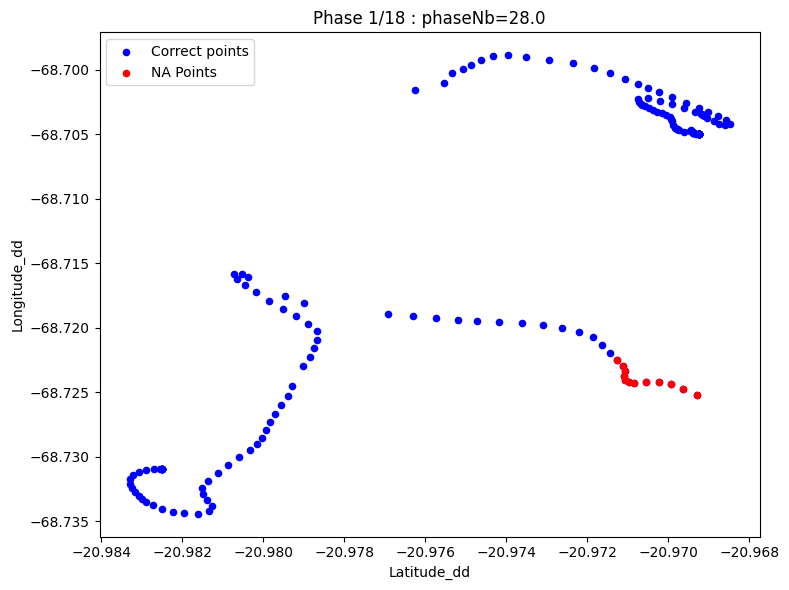

In [11]:
phases = tire1_na_values_df["phaseNb"].unique().tolist()
print(f"Number of phases with missing values : {len(phases)}")

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    tire1_df_sample = tire1_df[tire1_df["phaseNb"] == phase_nb]
    tire1_na_values_sample_df = tire1_na_values_df[tire1_na_values_df["phaseNb"] == phase_nb]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(tire1_df_sample['Latitude_dd'], tire1_df_sample['Longitude_dd'], s=20, c="blue", label="Correct points")
    ax.scatter(tire1_na_values_sample_df['Latitude_dd'], tire1_na_values_sample_df['Longitude_dd'], s=20, c="red", label="NA Points")
    ax.set_title(f"Phase {i+1}/{len(phases)} : phaseNb={phase_nb}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break

We can see that records with at least one missing value are mostly consecutive and are often followed by missing records in other variables as well (including GPS coordinates).  
This likely indicates that these sequences correspond to periods when the sensors stop transmitting data due to issues with the 3G network—for example, when the vehicle is deep in the mine and the network is too weak to even transmit GPS coordinates.

## c) Analyze the missing values for Tire 2 (front-right)

In this section, we realize the same missing values analysis for the tire 2 (front-right)

In [12]:
# Define the columns associated with this tire
tire2_df = df[[
    "Time_utc", "VehicleName", "VehicleType", "Pressure_Pa_2", "Temperature_K_2", "ColdPressure_Pa_2",
    "Latitude_dd", "Longitude_dd", "Altitude_m","Speed_mps", "epsilonX", "epsilonY", "epsilonZ",
    "epsilonSpeed","AtmosphericPressure_Pa", "dt_s", "dd_m", "RatioPayload", "phaseNb"
    ]]

In [13]:
# Identify rows with missing values in tire variables
mask_tire2_na_values = tire2_df[["Pressure_Pa_2", "Temperature_K_2", "ColdPressure_Pa_2"]].isna()

# Check our hypothesis about the correlation of missing values among the variables of the same tire
mask_tire2_na_values[(mask_tire2_na_values.sum(axis = 1) > 0) & (mask_tire2_na_values.sum(axis = 1) < 3)]

,Pressure_Pa_2,Temperature_K_2,ColdPressure_Pa_2


-> For Tire 2, there are no records where only one of the three tire variables is missing while the others are present.

In [14]:
# Get the indices of rows with at least one missing value in a tire variable
tire2_na_values_df = tire2_df[mask_tire2_na_values.any(axis = 1)]
tire2_na_values_index = tire2_na_values_df.index

Create a loop to display trajectories (phases) that contain at least one record with a missing value.  
Blue points correspond to records without missing values, while red points correspond to records with at least one missing value.

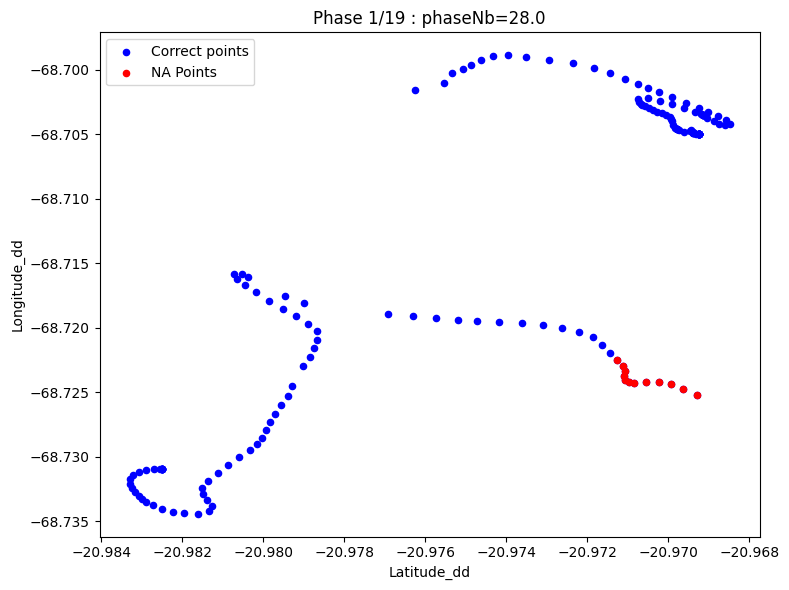

In [15]:
phases = tire2_na_values_df["phaseNb"].unique().tolist()
print(f"Number of phases with missing values : {len(phases)}")

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    tire2_df_sample = tire2_df[tire2_df["phaseNb"] == phase_nb]
    tire2_na_values_sample_df = tire2_na_values_df[tire2_na_values_df["phaseNb"] == phase_nb]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(tire2_df_sample['Latitude_dd'], tire2_df_sample['Longitude_dd'], s=20, c="blue", label="Correct points")
    ax.scatter(tire2_na_values_sample_df['Latitude_dd'], tire2_na_values_sample_df['Longitude_dd'], s=20, c="red", label="NA Points")
    ax.set_title(f"Phase {i+1}/{len(phases)} : phaseNb={phase_nb}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break

As with Tire 1, we can see that records with at least one missing value are mostly consecutive and are often followed by missing records in other variables as well (including GPS coordinates).  
Therefore, we can draw the same conclusions as we did for Tire 1.

We have not included the missing values analysis for the other tires because we reach the same conclusions, so it is unnecessary to include them here.

## d) Analyze missing values for the Atmospheric Pressure variable

In this section, we will analyze records with missing values for the "Atmospheric Pressure" variable, which are not related to any specific tire.

In [16]:
# Define the columns associated with this variable
appa_df = df[[
    "Time_utc", "VehicleName", "VehicleType", "AtmosphericPressure_Pa", "Latitude_dd", "Longitude_dd",
    "Altitude_m","Speed_mps", "epsilonX", "epsilonY", "epsilonZ", "epsilonSpeed","AtmosphericPressure_Pa", "dt_s", "dd_m", "RatioPayload",
    "phaseNb"
    ]]

In [17]:
# Identify rows with missing values in this variable
mask_appa_na_values = appa_df[["AtmosphericPressure_Pa"]].isna()
appa_na_values_df = appa_df[mask_appa_na_values.any(axis = 1)]
appa_na_values_index = appa_na_values_df.index

Create a loop to display trajectories (phases) that contain at least one record with a missing value.  
Blue points correspond to records without missing values, while red points correspond to records with at least one missing value.

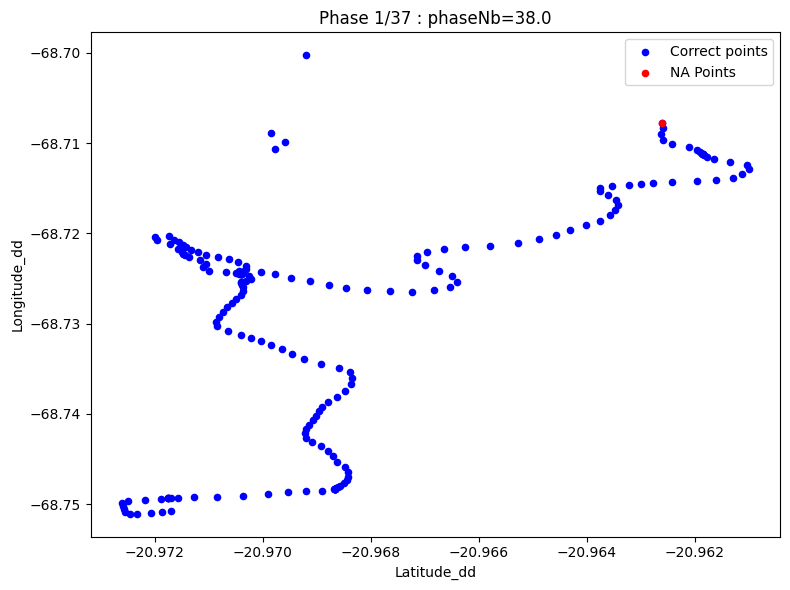

In [18]:
phases = appa_na_values_df["phaseNb"].unique().tolist()
print(f"Number of phases with missing values : {len(phases)}")

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    appa_df_sample = appa_df[appa_df["phaseNb"] == phase_nb]
    appa_na_values_sample_df = appa_na_values_df[appa_na_values_df["phaseNb"] == phase_nb]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(appa_df_sample['Latitude_dd'], appa_df_sample['Longitude_dd'], s=20, c="blue", label="Correct points")
    ax.scatter(appa_na_values_sample_df['Latitude_dd'], appa_na_values_sample_df['Longitude_dd'], s=20, c="red", label="NA Points")
    ax.set_title(f"Phase {i+1}/{len(phases)} : phaseNb={phase_nb}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break

Logically, we reach the same conclusions as in the two previous sections regarding the missing records.

## e) Missing records analysis

In this final section of the Missing Values Analysis, we will identify and analyze missing records for the vehicle within the trajectories.  

To do this, we will use the fact that each GPS coordinate and other variables, such as tire pressures, atmospheric pressure, etc., are recorded every 5 seconds.  

Moreover, we have a variable called "dt_s," which corresponds to the elapsed time since the previous record within a trajectory.  
Therefore, if the "dt_s" value is 10 seconds, we can deduce that one record is missing before it.

In [19]:
# Set the tolerance for the time interval between two records (in seconds)
dt_s_tolerance = 0.5
# Expected time interval between two records (in seconds)
original_dt_s = 5

# Initialize a column indicating no missing records by default
df["missing_record"] = False

# Mark as True the rows where the time gap exceeds the tolerance (potentially missing records)
df.loc[(df["dt_s"] - original_dt_s).abs() > dt_s_tolerance, "missing_record"] = True

# Display the first rows to check the result
df[["Time_utc", "Latitude_dd", "Longitude_dd", "dt_s", "missing_record"]].head(3)

,Time_utc,Latitude_dd,Longitude_dd,dt_s,missing_record
0,2023-01-01 00:00:00.328,-20.960378,-68.708935,4.912,False
1,2023-01-01 00:00:05.338,-20.960730,-68.709170,5.010,False
2,2023-01-01 00:00:10.331,-20.961045,-68.709473,4.993,False


In [20]:
# Create a DataFrame with only the rows where a missing record was detected
missing_records_df = df[df["missing_record"]][["Latitude_dd", "Longitude_dd", "dt_s", "missing_record", "phaseNb"]].copy()

# Calculate the number of missing records for each row based on the time gap
missing_records_df["nb_missing_records"] = ((missing_records_df["dt_s"] - original_dt_s) / original_dt_s).round(2)

# Display the resulting DataFrame
missing_records_df.head(3)

,Latitude_dd,Longitude_dd,dt_s,missing_record,phaseNb,nb_missing_records
8,-20.962785,-68.705493,25.098,True,0.0,4.02
22,-20.968675,-68.696763,15.122,True,0.0,2.02
138,-20.969360,-68.704337,9.958,True,0.0,0.99


In [61]:
missing_records_df.to_excel("missing_records.xlsx", header=True)

In [21]:
# Group by phaseNb and sum the number of missing records for each phase
missing_records_grouped = missing_records_df.groupby(["phaseNb"])["nb_missing_records"].sum().astype(int)

# Display the total number of missing records per phase
missing_records_grouped

phaseNb
0.0       7
1.0       0
3.0      11
4.0       6
5.0       1
         ..
520.0    83
521.0    19
522.0    49
523.0     3
524.0    23
Name: nb_missing_records, Length: 364, dtype: int64

In [22]:
# Compute the total number of records per phase
phase_nb_df = pd.DataFrame(df.groupby("phaseNb", as_index=True).size(), columns=["NbRecords"])

# Add the number of missing records per phase
phase_nb_df["NbMissingRecords"] = missing_records_grouped

# Replace NaN values (phases with no missing records) with 0
phase_nb_df["NbMissingRecords"].fillna(0, inplace=True)

# Ensure the column is of integer type
phase_nb_df["NbMissingRecords"] = phase_nb_df["NbMissingRecords"].astype(int)

# Calculate the missing record rate (%) for each phase
phase_nb_df["MissingRate (%)"] = ((phase_nb_df["NbMissingRecords"] / (phase_nb_df["NbMissingRecords"] + phase_nb_df["NbRecords"])) * 100).round(1)

# Display the resulting DataFrame
phase_nb_df

C:\Users\natha\AppData\Local\Temp\ipykernel_4552\4062268355.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  phase_nb_df["NbMissingRecords"].fillna(0, inplace=True)


,NbRecords,NbMissingRecords,MissingRate (%)
phaseNb,,,
0.0,196,7,3.4
1.0,321,0,0.0
2.0,126,0,0.0
3.0,307,11,3.5
4.0,606,6,1.0
...,...,...,...
521.0,270,19,6.6
522.0,273,49,15.2
523.0,485,3,0.6


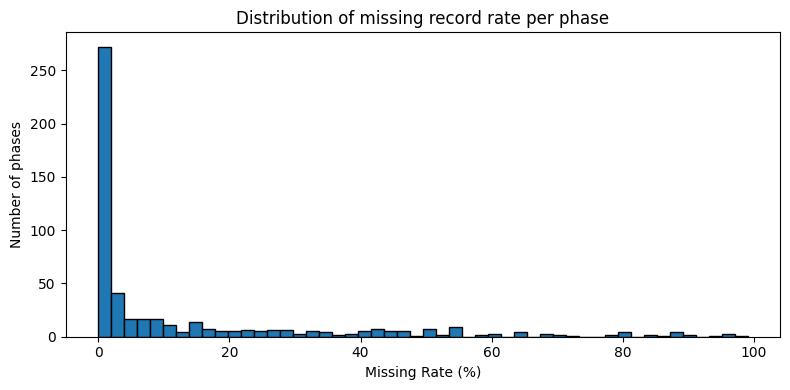

In [23]:
plt.figure(figsize=(8,4))
plt.hist(phase_nb_df["MissingRate (%)"], bins=50, color='tab:blue', edgecolor='black')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Number of phases")
plt.title("Distribution of missing record rate per phase")
plt.tight_layout()
plt.show()

C:\Users\natha\AppData\Local\Temp\ipykernel_4552\4134376475.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


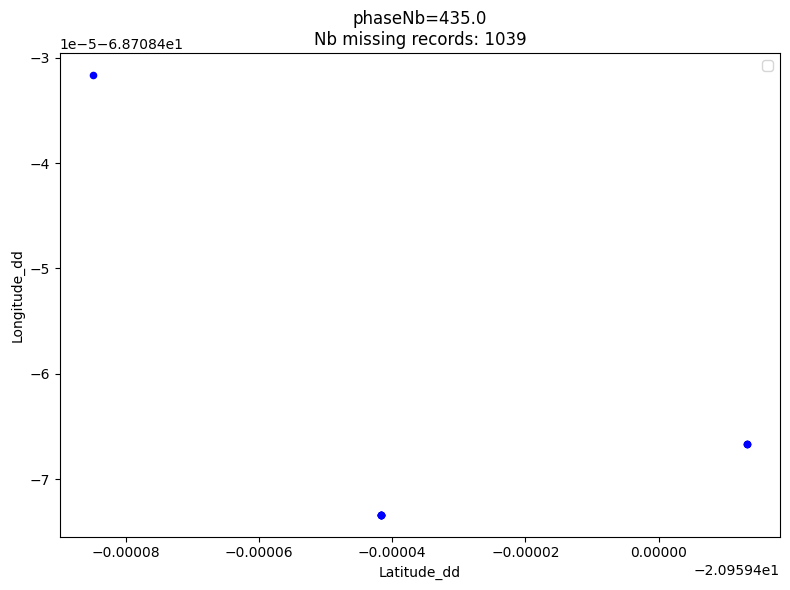

In [24]:
sorted_phase_nb_df = phase_nb_df.sort_values(by="MissingRate (%)", ascending=False)

phases = sorted_phase_nb_df.index.tolist()

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    df_sample = df[df["phaseNb"] == phase_nb]
    nb_missing_records = sorted_phase_nb_df.loc[phase_nb, "NbMissingRecords"]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(df_sample['Latitude_dd'], df_sample['Longitude_dd'], s=20, c="blue")
    ax.set_title(f"phaseNb={phase_nb}\nNb missing records: {nb_missing_records}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if i < len(phases)-1:
        resp = input('Press Enter to proceed to the next phase (or type "N" to exit the loop)...')
        if resp == "N":
            break

## f) Trajectory quality filtering

For trajectory clustering, large temporal gaps can affect distance calculations and clustering results.

We therefore apply a simple quality-based filtering using the percentage of missing records per trajectory.

Trajectories with a missing record rate below a fixed threshold are retained for further analysis, while those exceeding this threshold are excluded.

In [25]:
# Maximum acceptable percentage of missing records per trajectory
MISSING_THRESHOLD = 10  # %

# Split trajectories based on missing record rate
acceptable_phases = phase_nb_df[
    phase_nb_df["MissingRate (%)"] <= MISSING_THRESHOLD
].index.tolist()

low_quality_phases = phase_nb_df[
    phase_nb_df["MissingRate (%)"] > MISSING_THRESHOLD
].index.tolist()

# Filter the main DataFrame
df_acceptable = df[df["phaseNb"].isin(acceptable_phases)].copy()
df_low_quality = df[df["phaseNb"].isin(low_quality_phases)].copy()

print(f"Trajectories retained for analysis: {len(acceptable_phases)}")
print(f"Trajectories excluded due to low quality: {len(low_quality_phases)}")

Trajectories retained for analysis: 366
Trajectories excluded due to low quality: 160


## 3) Interpolating missing GPS position 

In this part, we implement a cubic spline interpolation

a) functions to compute interpolation 

In [26]:
def add_points_in_gaps(df_in: pd.DataFrame, threshold_dt_s: int, step_s: int = 5) -> pd.DataFrame:
    df_result = df_in.copy()
    
    df_result["Time_utc"] = pd.to_datetime(df_result["Time_utc"], format='mixed')
    
    # Tri par temps
    df_result = df_result.sort_values("Time_utc")
    
    # Recalcul de dt_s 
    df_result["dt_s"] = df_result["Time_utc"].diff().dt.total_seconds()

    mask = df_result["dt_s"] > threshold_dt_s
    gaps = df_result.loc[mask].copy()


    gaps["prev_Time_utc"] = df_result["Time_utc"].shift(1).loc[mask]
    
    # Calcul du nombre de points à ajouter (avec marge de sécurité -0.1)
    gaps["nb_points_to_add"] = ((gaps["dt_s"] - 0.1) // step_s).astype(int)

    new_rows_list = []

    print(f"Nombre de trous détectés : {len(gaps)}")
    
    for idx, row in gaps.iterrows():
        start_time = row["prev_Time_utc"] 
        nb_points = row["nb_points_to_add"]
        
        if nb_points > 0:
            
            new_dates = pd.date_range(
                start=start_time + pd.Timedelta(seconds=step_s), 
                periods=nb_points, 
                freq=f"{step_s}s"
            )
            
            temp_df = pd.DataFrame(index=range(nb_points))
            temp_df["Time_utc"] = new_dates
            
            for col in ["phaseNb", "RatioPayload"]: 
                if col in row:
                    temp_df[col] = row[col] 
            
            temp_df["is_added"] = True
            new_rows_list.append(temp_df)

    if new_rows_list:
        df_new_points = pd.concat(new_rows_list)
        df_out = pd.concat([df_result, df_new_points])
        df_out = df_out.sort_values("Time_utc").reset_index(drop=True)
        
        df_out["dt_s"] = df_out["Time_utc"].diff().dt.total_seconds()
        return df_out
    else:
        return df_result

In [27]:
def interpolate_trajectory_spline(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()

    t0 = df_out["Time_utc"].min()
    df_out["seconds_relative"] = (df_out["Time_utc"] - t0).dt.total_seconds()

    mask_known = df_out['Latitude_dd'].notna() & df_out['Longitude_dd'].notna()
    
    t_known = df_out.loc[mask_known, "seconds_relative"].values
    
    t_target = df_out["seconds_relative"].values

    # Projection (GPS -> Mètres)
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:32719", always_xy=True)
        
    lon_known = df_out.loc[mask_known, 'Longitude_dd'].values
    lat_known = df_out.loc[mask_known, 'Latitude_dd'].values
    
    x_meters_known, y_meters_known = transformer.transform(lon_known, lat_known)


    k_val = 3 if len(t_known) > 3 else 1 
    
    spl_x = make_interp_spline(t_known, x_meters_known, k=k_val)
    spl_y = make_interp_spline(t_known, y_meters_known, k=k_val)


    x_new_meters = spl_x(t_target)
    y_new_meters = spl_y(t_target)

    lon_new, lat_new = transformer.transform(x_new_meters, y_new_meters, direction='INVERSE')

  
    df_out['Latitude_dd'] = lat_new
    df_out['Longitude_dd'] = lon_new
    
    df_out = df_out.drop(columns=["seconds_relative"])

    return df_out

In [28]:
def full_reconstruction_by_phase(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    1. Remplit les capteurs (Pression, Temp, etc.) par interpolation linéaire.
    2. RECALCULE la vitesse manquante à partir de la distance parcourue (Lat/Lon).
    3. Ne modifie PAS les valeurs existantes.
    """
    df = df_in.copy()

    # --- 1. CONFIGURATION ---
    if df['Time_utc'].dtype == 'O':
        df['Time_utc'] = pd.to_datetime(df['Time_utc'])
    
    df = df.sort_values(by=['phaseNb', 'Time_utc'])
    df = df.set_index('Time_utc')

    # --- 2. INTERPOLATION LINÉAIRE (CAPTEURS) ---
    # On exclut Speed_mps car on va le traiter physiquement juste après
    keywords = ['Pressure', 'Temperature', 'Altitude', 'dd_m', 'epsilon']
    sensor_cols = [c for c in df.columns if any(x in c for x in keywords)]
    
    print(f"Interpolation linéaire des capteurs : {len(sensor_cols)} colonnes")
    
    for col in sensor_cols:
        df[col] = df.groupby('phaseNb')[col].transform(
            lambda x: x.interpolate(method='time', limit_direction='both')
        )

    # --- 3. CALCUL PHYSIQUE DE LA VITESSE (POUR LES TROUS) ---
    if 'Speed_mps' in df.columns and 'Latitude_dd' in df.columns:
        print("Recalcul de la vitesse pour les points manquants...")
        
        # A. Projection en Mètres (Zone Chili 19S)
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:32719", always_xy=True)
        x, y = transformer.transform(df['Longitude_dd'].values, df['Latitude_dd'].values)
        
        # B. Création d'un DF temporaire pour les calculs vectoriels
        # On a besoin du contexte (phaseNb) pour ne pas calculer de vitesse entre deux phases
        calc_df = pd.DataFrame({
            'x': x, 
            'y': y, 
            'phaseNb': df['phaseNb'].values
        }, index=df.index)
        
        # C. Calcul des Différences (Delta Pos / Delta Temps)
        dx = calc_df.groupby('phaseNb')['x'].diff()
        dy = calc_df.groupby('phaseNb')['y'].diff()
        dist_m = np.sqrt(dx**2 + dy**2)
        
        # Delta Temps en secondes
        dt_s = calc_df.index.to_series().groupby(calc_df['phaseNb']).diff().dt.total_seconds()
        
        # D. Vitesse (m/s)
        # On gère la division par zéro ou NaN
        v_calc = dist_m / dt_s
        
        # E. Remplissage intelligent
        # On ne remplit QUE les trous. Si le capteur vitesse a parlé, on le croit.
        df['Speed_mps'] = df['Speed_mps'].fillna(v_calc)

    # --- 4. DONNÉES STATIQUES ---
    static_cols = ['VehicleName', 'VehicleType', 'RatioPayload']
    existing_static = [c for c in static_cols if c in df.columns]
    if existing_static:
        df[existing_static] = df.groupby('phaseNb')[existing_static].transform(
            lambda x: x.ffill().bfill()
        )

    return df.reset_index()

### b) tests

In [29]:
def run_interpolation_test(df_complete: pd.DataFrame, 
                           gap_duration_s: int = 30, 
                           start_time=None, 
                           phase_id=None, 
                           total_view_s: int = 100):
    print(f"--- Lancement du test (Trou: {gap_duration_s}s, Fenêtre: {total_view_s}s) ---")
    
    df_subset = df_complete.copy()
    

    if not pd.api.types.is_datetime64_any_dtype(df_subset["Time_utc"]):
        print("Conversion de la colonne Time_utc en datetime...")
        try:
            df_subset["Time_utc"] = pd.to_datetime(df_subset["Time_utc"], format='mixed')
        except Exception:
            df_subset["Time_utc"] = pd.to_datetime(df_subset["Time_utc"])

    if phase_id is not None:
        if "phaseNb" not in df_subset.columns:
            print("Attention: 'phaseNb' non trouvé, filtre ignoré.")
        else:
            df_subset = df_subset[df_subset["phaseNb"] == phase_id].copy()
            print(f"-> Filtré sur la phase {phase_id}")

    if df_subset.empty:
        print("Erreur: Dataframe vide après filtrage.")
        return

    df_subset = df_subset.sort_values("Time_utc")

    t_min_avail = df_subset["Time_utc"].min()
    t_max_avail = df_subset["Time_utc"].max()
    
    if start_time is None:
        # we select the middle of the phase
        full_duration = (t_max_avail - t_min_avail).total_seconds()
        offset = (full_duration - total_view_s) / 2
        window_start = t_min_avail + pd.Timedelta(seconds=max(0, offset))
    else:
        window_start = pd.to_datetime(start_time)
        if window_start < t_min_avail or window_start > t_max_avail:
            print(f"Attention: L'heure demandée {window_start} est hors limites.")
            print(f"Dispo: {t_min_avail} à {t_max_avail}")
            return

    window_end = window_start + pd.Timedelta(seconds=total_view_s)
    
    mask_window = (df_subset["Time_utc"] >= window_start) & (df_subset["Time_utc"] <= window_end)
    segment_truth = df_subset.loc[mask_window].copy()
    
    if len(segment_truth) < 2:
        print("Erreur: Pas assez de points dans la fenêtre choisie.")
        return

    segment_test = segment_truth.copy()
    
    hole_center = window_start + pd.Timedelta(seconds=total_view_s / 2)
    hole_start = hole_center - pd.Timedelta(seconds=gap_duration_s / 2)
    hole_end = hole_center + pd.Timedelta(seconds=gap_duration_s / 2)
    
    mask_hole = (segment_test["Time_utc"] > hole_start) & (segment_test["Time_utc"] < hole_end)
    
    ground_truth_values = segment_test.loc[mask_hole].copy()
    segment_test.loc[mask_hole, ["Latitude_dd", "Longitude_dd"]] = np.nan
    
    print(f"-> Test sur plage : {window_start.time()} à {window_end.time()}")
    print(f"-> Trou créé de   : {hole_start.time()} à {hole_end.time()} ({mask_hole.sum()} points masqués)")

    try:
        df_interpolated = interpolate_trajectory_spline(segment_test)
    except Exception as e:
        print(f"Erreur lors de l'interpolation : {e}")
        # On print le type de Time_utc pour debugger si ça recasse
        print(f"Type de Time_utc : {segment_test['Time_utc'].dtype}")
        return
    
    predicted_values = df_interpolated.loc[mask_hole]
    
    if predicted_values.empty:
        print("Attention: Aucun point n'a été interpolé dans la zone du trou.")
    else:
        err_lat = predicted_values["Latitude_dd"] - ground_truth_values["Latitude_dd"]
        err_lon = predicted_values["Longitude_dd"] - ground_truth_values["Longitude_dd"]
        err_meters = np.sqrt((err_lat * 111132)**2 + (err_lon * 78847)**2)
        
        print(f"Erreur moyenne : {err_meters.mean():.2f} m")
        print(f"Erreur max     : {err_meters.max():.2f} m")

    plt.figure(figsize=(10, 6))
    mask_input = segment_test["Latitude_dd"].notna()
    plt.plot(segment_test.loc[mask_input, "Longitude_dd"], segment_test.loc[mask_input, "Latitude_dd"], 
             'ko', label="Données conservées", markersize=4, alpha=0.5)
    plt.plot(ground_truth_values["Longitude_dd"], ground_truth_values["Latitude_dd"], 
             'gx', linewidth=2, label="Vérité Terrain (Cachée)")
    plt.plot(predicted_values["Longitude_dd"], predicted_values["Latitude_dd"], 
             'r.', label="Interpolation (Spline)", markersize=6)
    
    plt.legend()
    plt.title(f"Validation : Trou de {gap_duration_s}s (Phase {phase_id if phase_id else 'All'})")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal')
    plt.show()

--- Lancement du test (Trou: 10s, Fenêtre: 100s) ---
-> Filtré sur la phase 40
-> Test sur plage : 20:21:36.391500 à 20:23:16.391500
-> Trou créé de   : 20:22:21.391500 à 20:22:31.391500 (3 points masqués)
Erreur moyenne : 3.88 m
Erreur max     : 7.22 m


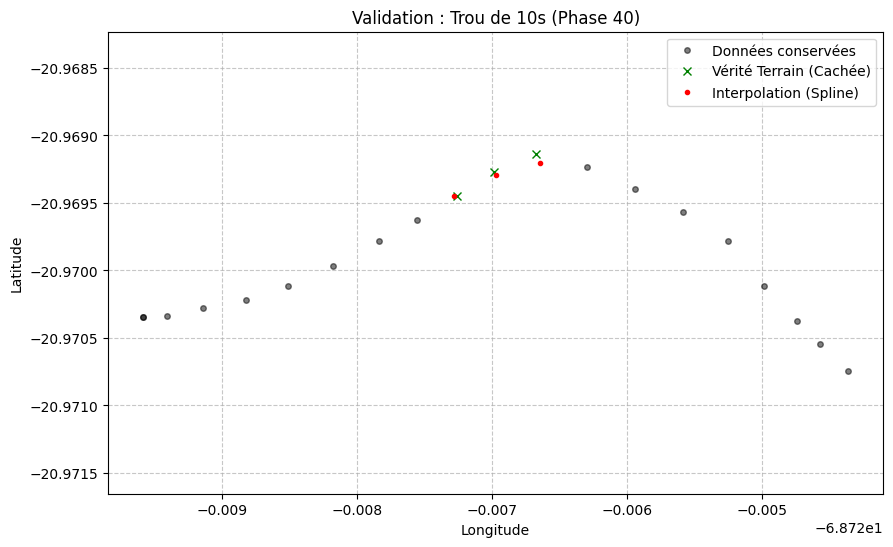

In [30]:
run_interpolation_test(df_acceptable, phase_id=40, gap_duration_s=10)

### c) Use 

In [31]:
df_filled = add_points_in_gaps(df_acceptable, 5, 5)
df_complete = interpolate_trajectory_spline(df_filled) 

df_complete["is_added"] = df_complete["is_added"].fillna(False).astype(bool)
df_final = full_reconstruction_by_phase(df_complete)

Nombre de trous détectés : 72039


C:\Users\natha\AppData\Local\Temp\ipykernel_4552\2440102971.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_complete["is_added"] = df_complete["is_added"].fillna(False).astype(bool)


Interpolation linéaire des capteurs : 25 colonnes
Recalcul de la vitesse pour les points manquants...


In [32]:
df_final

,Time_utc,VehicleName,VehicleType,Pressure_Pa_1,Pressure_Pa_2,Pressure_Pa_3,Pressure_Pa_4,Pressure_Pa_5,Pressure_Pa_6,Temperature_K_1,...,epsilonY,epsilonZ,epsilonSpeed,AtmosphericPressure_Pa,dt_s,dd_m,RatioPayload,phaseNb,missing_record,is_added
0,2023-01-01 00:00:05.338,C-132,Dumper,993177.933329,1.003911e+06,856000.0,798088.966665,819911.033335,864911.033335,346.15,...,6.797000,27.600000,0.000000,59028.296172,NaN,45.952211,0.0,0.0,False,False
1,2023-01-01 00:00:10.331,C-132,Dumper,993344.366669,1.003828e+06,856000.0,798172.183334,819827.816666,864827.816666,346.15,...,7.631000,32.200001,0.000000,59064.789917,4.993,47.007842,0.0,0.0,False,False
2,2023-01-01 00:00:15.325,C-132,Dumper,993510.833331,1.003745e+06,856000.0,798255.416666,819744.583334,864744.583334,346.15,...,6.504000,23.000000,0.000000,59101.596928,4.994,48.700870,0.0,0.0,False,False
3,2023-01-01 00:00:20.325,C-132,Dumper,993677.499998,1.003661e+06,856000.0,798338.749999,819661.250001,864661.250001,346.15,...,7.128634,23.000000,0.000000,59138.448160,5.000,52.579971,0.0,0.0,NaN,True
4,2023-01-01 00:00:20.448,C-132,Dumper,993681.600000,1.003659e+06,856000.0,798340.800000,819659.200000,864659.200000,346.15,...,7.144000,23.000000,0.000000,59139.354701,0.123,52.675397,0.0,0.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243761,2023-01-14 23:59:40.000,C-132,Dumper,984333.333333,9.570000e+05,838000.0,765333.333333,805000.000000,834333.333333,332.15,...,9.155000,27.600000,19.090000,58979.989211,5.000,25.962443,1.0,525.0,False,False
243762,2023-01-14 23:59:45.000,C-132,Dumper,983250.000000,9.572500e+05,838000.0,764750.000000,805125.000000,834750.000000,332.15,...,10.977000,27.600000,21.760000,58966.292928,5.000,16.829179,1.0,525.0,False,False
243763,2023-01-14 23:59:50.000,C-132,Dumper,982166.666667,9.575000e+05,838000.0,764166.666667,805250.000000,835166.666667,332.15,...,9.837000,23.000000,19.450001,58953.265633,5.000,18.573442,1.0,525.0,False,False
243764,2023-01-14 23:59:55.000,C-132,Dumper,981083.333333,9.577500e+05,838000.0,763583.333333,805375.000000,835583.333333,332.15,...,13.652000,27.600000,24.230000,58939.706055,5.000,17.233455,1.0,525.0,False,False


---
# 4) Clustering on Aggregated Features

### a) Feature generation

In [33]:
print("Aggregating trip features from telemetry data...")

df_features = df_final.groupby('phaseNb').agg(
    avg_speed=('Speed_mps', 'mean'),
    speed_std=('Speed_mps', 'std'),           
    payload=('RatioPayload', 'mean'),           
    alt_start=('Altitude_m', 'first'),
    alt_end=('Altitude_m', 'last'),
    distance_m=('dd_m', 'sum'),
    duration_s=('dt_s', 'sum'),
    temp_K_mean=('Temperature_K_3', 'mean'),    
    temp_K_max=('Temperature_K_3', 'max'),
    temp_K_min=('Temperature_K_3', 'min'),
    epsilonZ_abs_median=('epsilonZ', lambda x: x.abs().median()), 
    epsilonX_abs_median=('epsilonX', lambda x: x.abs().median())  
).reset_index()

# Engineering secondary physical metrics
df_features['alt_gain'] = df_features['alt_end'] - df_features['alt_start']
df_features['temp_delta'] = df_features['temp_K_max'] - df_features['temp_K_min']
df_features['slope_avg'] = (df_features['alt_gain'] / df_features['distance_m'].replace(0, np.nan)) * 100
df_features['slope_avg'] = df_features['slope_avg'].fillna(0)

# Selecting the most discriminative variables for operational clustering
cols_to_use = [
    'avg_speed', 
    'payload', 
    'alt_gain', 
    'duration_s', 
    'temp_K_mean', 
    'temp_delta', 
    'epsilonZ_abs_median',
    'slope_avg', 
    'epsilonX_abs_median'
]

print(f"Executing clustering on {len(cols_to_use)} features...")
X_subset = df_features[cols_to_use].copy()

# Handling potential infinite values and standardizing scales
X_subset = X_subset.replace([np.inf, -np.inf], np.nan).fillna(0)
X_scaled_clean = StandardScaler().fit_transform(X_subset)


Aggregating trip features from telemetry data...
Executing clustering on 9 features...


### b) HDBSCAN clustering

In [34]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25, 
    min_samples=10, 
    metric='manhattan', 
    gen_min_span_tree=True
)

df_features['cluster_clean'] = clusterer.fit_predict(X_scaled_clean)

n_clusters = len(set(df_features['cluster_clean'])) - (1 if -1 in df_features['cluster_clean'] else 0)
print(f"Clustering complete. Identified {n_clusters} distinct operational profiles.")

Clustering complete. Identified 4 distinct operational profiles.


### c) Model validation scores and clustering profiling

In [35]:
# Create a mask to exclude noise points (-1) from validation metrics
mask = df_features['cluster_clean'] != -1

if n_clusters > 1:
    sil_score = silhouette_score(X_scaled_clean[mask], df_features.loc[mask, 'cluster_clean'], metric='manhattan')
    db_score = davies_bouldin_score(X_scaled_clean[mask], df_features.loc[mask, 'cluster_clean'])
    
    print(f"\n--- MODEL VALIDATION ---")
    print(f"Silhouette Score (↑) : {sil_score:.3f}")
    print(f"Davies-Bouldin Index (↓) : {db_score:.3f} (Lower is better)")

    full_profiles = df_features.groupby('cluster_clean').agg(
        speed_kmh=('avg_speed', lambda x: x.median() * 3.6),
        slope_pct=('slope_avg', 'median'),
        payload_ratio=('payload', 'median'),
        temp_K=('temp_K_mean', 'median'),
        vibration_Z_vertical=('epsilonZ_abs_median', 'median'), 
        vibration_X_lateral=('epsilonX_abs_median', 'median'),  
        speed_nervousness=('speed_std', 'median'),             
        duration_min=('duration_s', lambda x: x.median() / 60),
        trip_count=('avg_speed', 'count')
    ).round(2)
    
    print("\n--- COMPREHENSIVE CLUSTER PROFILES ---")
    print(full_profiles)


--- MODEL VALIDATION ---
Silhouette Score (↑) : 0.461
Davies-Bouldin Index (↓) : 0.925 (Lower is better)

--- COMPREHENSIVE CLUSTER PROFILES ---
               speed_kmh  slope_pct  payload_ratio  temp_K  \
cluster_clean                                                
-1                 14.44      -0.58            0.0  332.91   
 0                 20.08      -2.19            0.0  335.74   
 1                 14.70       6.39            1.0  336.03   
 2                 22.50       0.99            1.0  335.79   

               vibration_Z_vertical  vibration_X_lateral  speed_nervousness  \
cluster_clean                                                                 
-1                             27.6                 8.42               3.34   
 0                             23.0                 7.60               4.50   
 1                             32.2                 9.09               2.18   
 2                             23.0                 7.44               3.48   

      

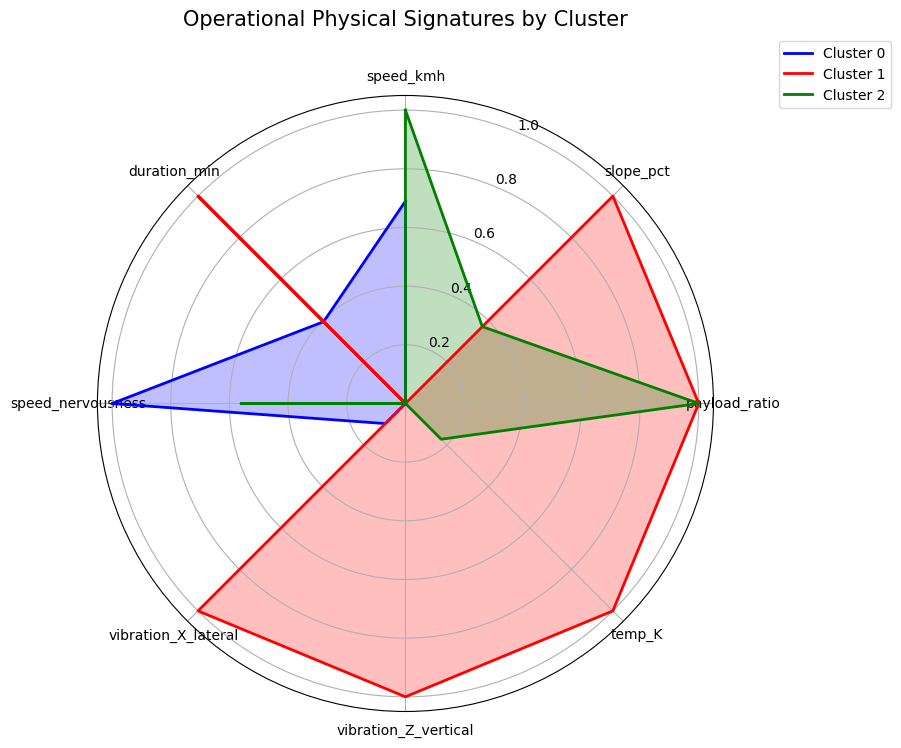

In [36]:
df_radar = full_profiles.loc[full_profiles.index != -1].drop(columns=['trip_count'])
df_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

labels = df_norm.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circular plot

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['blue', 'red', 'green', 'orange']

for i, (idx, row) in enumerate(df_norm.iterrows()):
    values = row.tolist()
    values += values[:1] 
    ax.plot(angles, values, color=colors[i % len(colors)], linewidth=2, label=f'Cluster {idx}')
    ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title("Operational Physical Signatures by Cluster", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

Cluster 1:  

Physical Context: With a 6.39% slope and a full load (1.0), the tire undergoes its maximum structural deformation.

Key Observations: 
-> Temperature: This cluster has the highest temperature (336.03 K).
-> Vibrations: Vertical vibrations are at their peak (32.2).

Driving Style: Speed "nervousness" is at its lowest (2.18). This is logical: on a steep incline, the driver maintains.

Cluster 2:

Physical Context: This phase represents high-speed hauling (22.5 km/h) on flat terrain (0.99% slope).

Key Observations:
-> Temperature: Despite the lack of an incline, the temperature (335.79 K) is nearly as high as the uphill climb. This proves that high speed compensates for the absence of a slope in generating heat.


Cluster 0: 

Physical Context: The truck is empty (0.0 load) and traveling at a moderate speed (14.94 km/h) on a negative slope (downhill).

Key Observations:
-> High Nervousness: This is where the speed instability (nervosite_vitesse) is at its highest (4.46). This is a classic indicator of approach phases, positioning the truck under the shovel, or frequent braking.

Thermal Impact: Tires cool down very little despite the lack of load because they are constantly stressed by changes in direction and frequent "stop-and-go" movements.

## d) K-Means clustering

In order to compare density-based clustering with a centroid-based approach, we apply K-Means using the same feature set and preprocessing as previously defined.

The optimal number of clusters is first estimated using the elbow method, and K-Means is then applied using the selected value of k.

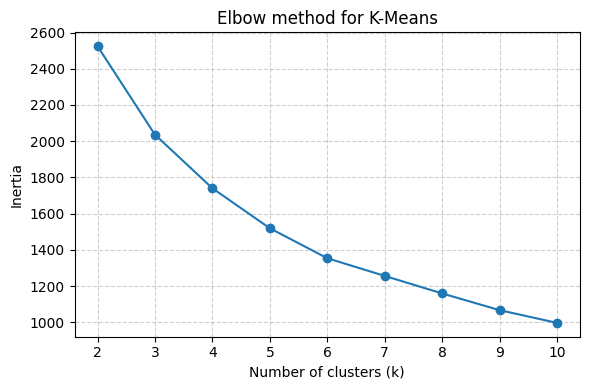

In [37]:
# Elbow method for K-Means
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    kmeans.fit(X_scaled_clean)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method for K-Means")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [38]:
k_opt = 4

kmeans = KMeans(
    n_clusters=k_opt,
    random_state=42,
    n_init=20
)

df_features['cluster_kmeans'] = kmeans.fit_predict(X_scaled_clean)

print(f"K-Means clustering completed with k = {k_opt}")


K-Means clustering completed with k = 4


In [39]:
sil_km = silhouette_score(
    X_scaled_clean, 
    df_features['cluster_kmeans'], 
    metric='manhattan'
)

db_km = davies_bouldin_score(
    X_scaled_clean, 
    df_features['cluster_kmeans']
)

print("\n--- K-MEANS VALIDATION ---")
print(f"Silhouette Score (↑) : {sil_km:.3f}")
print(f"Davies-Bouldin Index (↓) : {db_km:.3f}")


--- K-MEANS VALIDATION ---
Silhouette Score (↑) : 0.266
Davies-Bouldin Index (↓) : 1.310


Compared to HDBSCAN, K-Means shows significantly lower cluster separation and higher intra-cluster dispersion, confirming that a centroid-based approach is less suitable for this dataset.

## e) Hierarchical Clustering

To explore a different clustering perspective, we apply Hierarchical Clustering using the same set of standardized features.
The dendrogram helps visualize cluster separation and decide on a reasonable number of clusters.

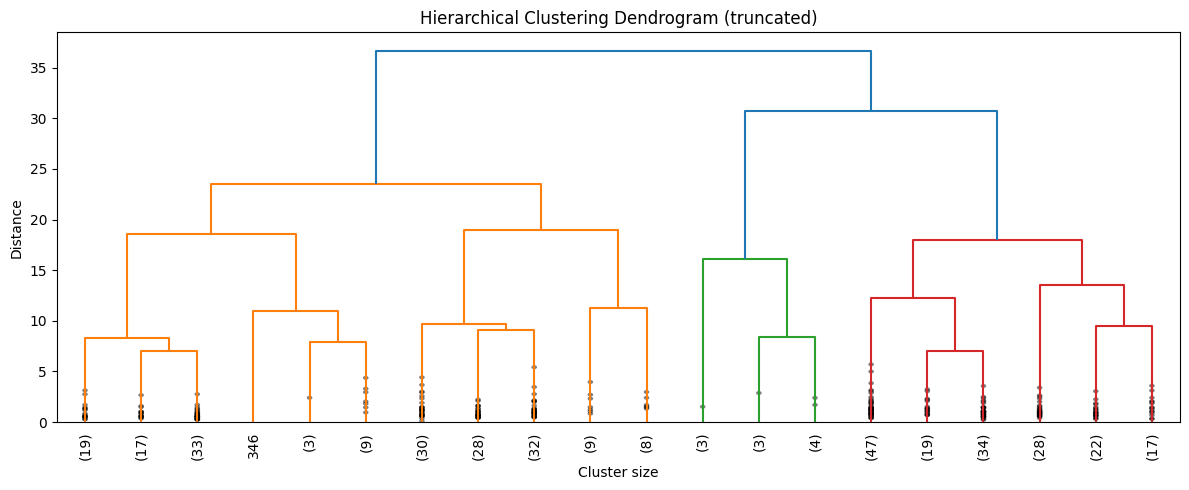

In [40]:
# Compute linkage matrix (Ward method, Euclidean distance)
Z = linkage(X_scaled_clean, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [41]:
n_clusters_hier = 3

# Create cluster labels
df_features['cluster_hier'] = fcluster(Z, t=n_clusters_hier, criterion='maxclust')

print(f"Hierarchical clustering completed with {n_clusters_hier} clusters")


Hierarchical clustering completed with 3 clusters


In [42]:
sil_hier = silhouette_score(X_scaled_clean, df_features['cluster_hier'], metric='euclidean')
db_hier = davies_bouldin_score(X_scaled_clean, df_features['cluster_hier'])

print("\n--- HIERARCHICAL CLUSTER VALIDATION ---")
print(f"Silhouette Score (↑) : {sil_hier:.3f}")
print(f"Davies-Bouldin Index (↓) : {db_hier:.3f}")



--- HIERARCHICAL CLUSTER VALIDATION ---
Silhouette Score (↑) : 0.258
Davies-Bouldin Index (↓) : 1.334


Hierarchical clustering shows similar performance to K-Means, with low cluster separation and moderate intra-cluster dispersion. HDBSCAN still provides the best clustering structure for this dataset.

## f)Gaussian Mixture Model (EM Algorithm)

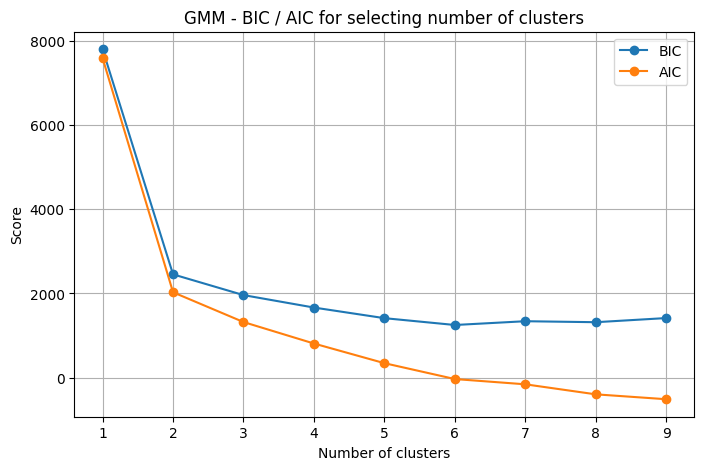

In [43]:
n_components = range(1, 10)  # tester de 1 à 9 clusters
bic_scores = []
aic_scores = []

for n in n_components:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_scaled_clean)
    bic_scores.append(gmm.bic(X_scaled_clean))
    aic_scores.append(gmm.aic(X_scaled_clean))

plt.figure(figsize=(8,5))
plt.plot(n_components, bic_scores, label='BIC', marker='o')
plt.plot(n_components, aic_scores, label='AIC', marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.title('GMM - BIC / AIC for selecting number of clusters')
plt.legend()
plt.grid(True)
plt.show()


In [44]:
n_clusters_em = 3

# Fit GMM
gmm = GaussianMixture(n_components=n_clusters_em, covariance_type='full', random_state=42)
df_features['cluster_em'] = gmm.fit_predict(X_scaled_clean)

# Validation scores
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_em = silhouette_score(X_scaled_clean, df_features['cluster_em'])
db_em = davies_bouldin_score(X_scaled_clean, df_features['cluster_em'])

print("\n--- GMM (EM) CLUSTER VALIDATION ---")
print(f"Silhouette Score (↑) : {sil_em:.3f}")
print(f"Davies-Bouldin Index (↓) : {db_em:.3f}")



--- GMM (EM) CLUSTER VALIDATION ---
Silhouette Score (↑) : 0.273
Davies-Bouldin Index (↓) : 1.387


Gaussian Mixture (EM) performs worse than HDBSCAN, with low cluster separation and higher intra-cluster dispersion. This confirms that a probabilistic centroid-based approach is not well suited for this dataset.

 ---
 # 5) Clustering Time Series Trajectories (TSKMeans)

In the previous section, we performed clustering on aggregated features computed per phase, such as average speed, payload, altitude gain, and vibration metrics. While this approach captures overall characteristics of each trajectory, it ignores the temporal dynamics and the detailed evolution of signals over time.

In this section, we focus on time series clustering using TSKMeans. Instead of using aggregated metrics, we leverage the full temporal sequences of selected telemetry features (Speed, Altitude, Payload, Temperature, Vibrations, etc.) for each phase. This allows us to group trajectories not only by their overall statistics, but also by the shape and evolution of their signals over time.

This approach helps reveal patterns in the trajectories that might be lost when using only aggregated features, providing a deeper understanding of operational behavior.

## a) Prepare Time Series Trajectories

In [45]:
# Select features
ts_features = [
    'Speed_mps', 
    'RatioPayload', 
    'Altitude_m', 
    'Temperature_K_3', 
    'epsilonZ', 
    'epsilonX', 
    'dd_m'
]

df_ts = df_acceptable.copy()
df_ts[ts_features] = df_ts[ts_features].ffill().bfill()

#Create list of trajectories per phase
trajectories = []
trajectory_ids = df_ts['phaseNb'].unique()

for phase in trajectory_ids:
    df_phase = df_ts[df_ts['phaseNb'] == phase].sort_values('Time_utc')
    X = df_phase[ts_features].values
    if X.shape[0] > 1:
        trajectories.append(X)

print(f"Number of valid trajectories: {len(trajectories)}")


Number of valid trajectories: 366


## b) Resample Trajectories to Same Length

In [46]:
# Resample all trajectories to a common length
# Use the 90th percentile of trajectory lengths to avoid extreme short or long series
length_percentile = int(np.percentile([x.shape[0] for x in trajectories], 90))
resampler = TimeSeriesResampler(sz=length_percentile)
trajectories_resampled = resampler.fit_transform(trajectories)

print(f"Shape after resampling: {trajectories_resampled.shape}")


Shape after resampling: (366, 766, 7)


## c) Elbow Method for TSKMeans

Fitting TSKMeans for k=2 ...
Fitting TSKMeans for k=3 ...
Fitting TSKMeans for k=4 ...
Fitting TSKMeans for k=5 ...
Fitting TSKMeans for k=6 ...
Fitting TSKMeans for k=7 ...
Fitting TSKMeans for k=8 ...
Fitting TSKMeans for k=9 ...
Fitting TSKMeans for k=10 ...
Fitting TSKMeans for k=11 ...
Fitting TSKMeans for k=12 ...
Fitting TSKMeans for k=13 ...
Fitting TSKMeans for k=14 ...
Fitting TSKMeans for k=15 ...
Fitting TSKMeans for k=16 ...
Fitting TSKMeans for k=17 ...
Fitting TSKMeans for k=18 ...
Fitting TSKMeans for k=19 ...
Fitting TSKMeans for k=20 ...
Fitting TSKMeans for k=21 ...
Fitting TSKMeans for k=22 ...
Fitting TSKMeans for k=23 ...
Fitting TSKMeans for k=24 ...


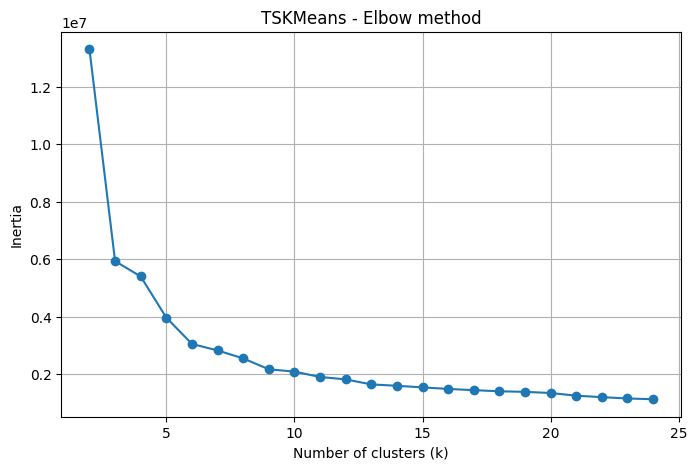

In [47]:
inertia_list = []
K_range = range(2, 25)

for k in K_range:
    print(f"Fitting TSKMeans for k={k} ...")
    km = TimeSeriesKMeans(n_clusters=k, metric="euclidean", random_state=42)
    km.fit(trajectories_resampled)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_list, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("TSKMeans - Elbow method")
plt.grid(True)
plt.show()


## d) Fit TSKMeans with Optimal k

In [48]:
k_opt = 4
tskmeans = TimeSeriesKMeans(n_clusters=k_opt, metric="euclidean", random_state=42)
labels = tskmeans.fit_predict(trajectories_resampled)

# Map labels back to each phase
df_ts['cluster_ts'] = df_ts['phaseNb'].map(dict(zip(trajectory_ids, labels)))
print(f"TSKMeans clustering completed with {k_opt} clusters")


TSKMeans clustering completed with 4 clusters


## e) Visualize Trajectories by Cluster

In [49]:
## Map cluster labels back to the phases 
# Create a mapping phaseNb -> cluster
phase_to_cluster = dict(zip(trajectory_ids, labels))

# Add cluster labels to df_ts
df_ts['cluster_ts'] = df_ts['phaseNb'].map(phase_to_cluster)


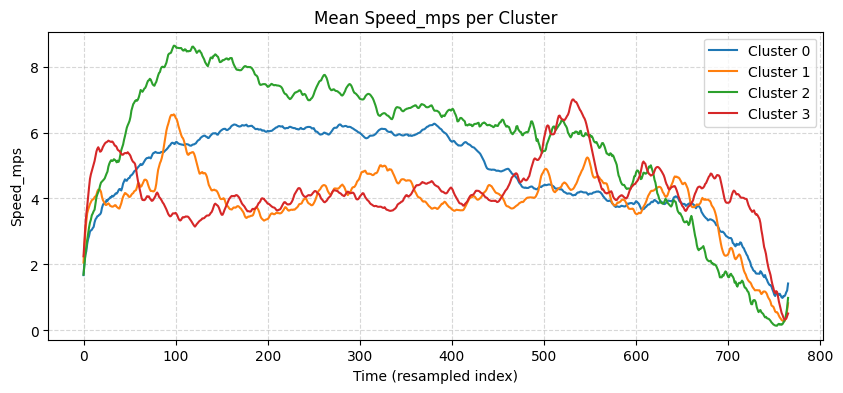

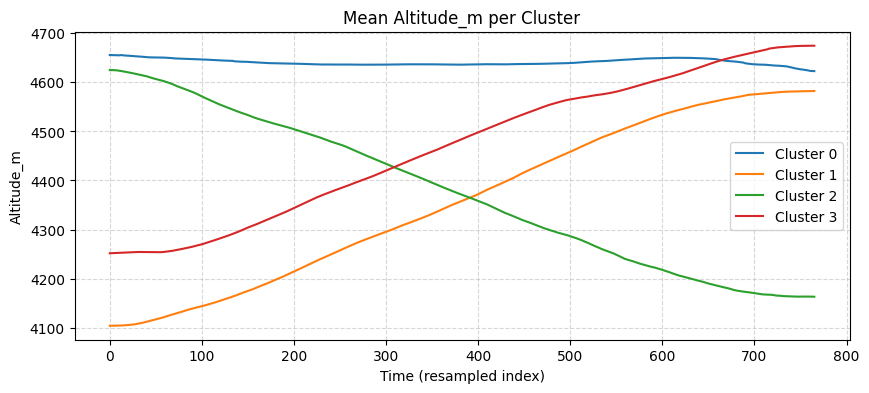

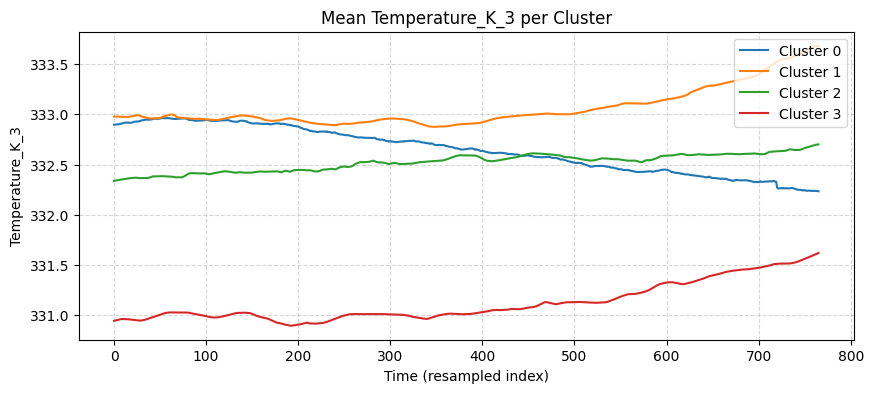

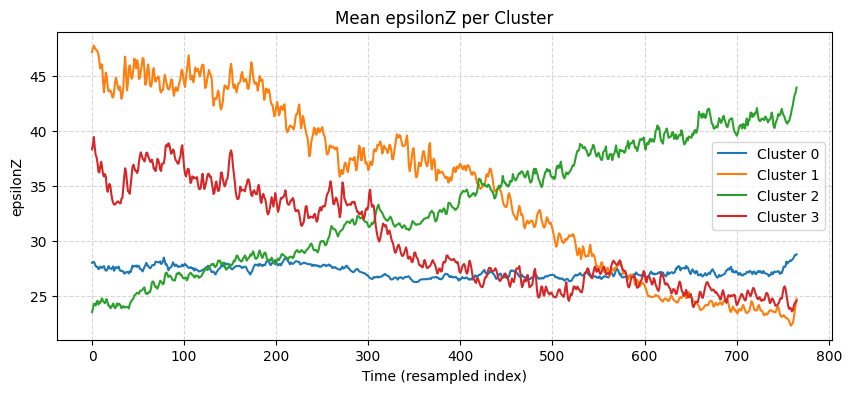

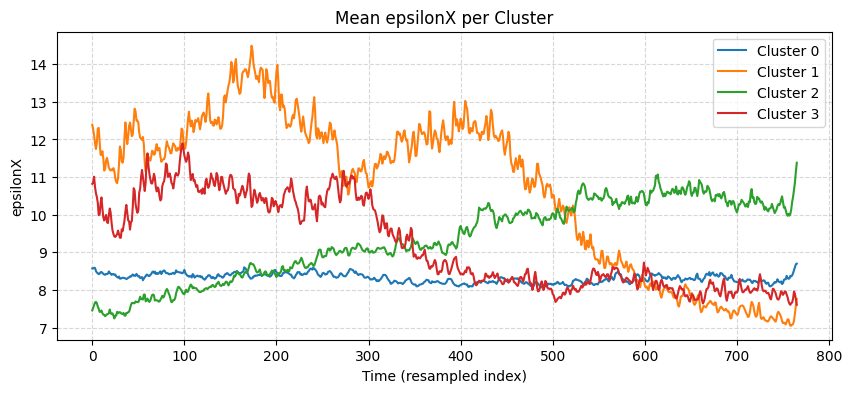

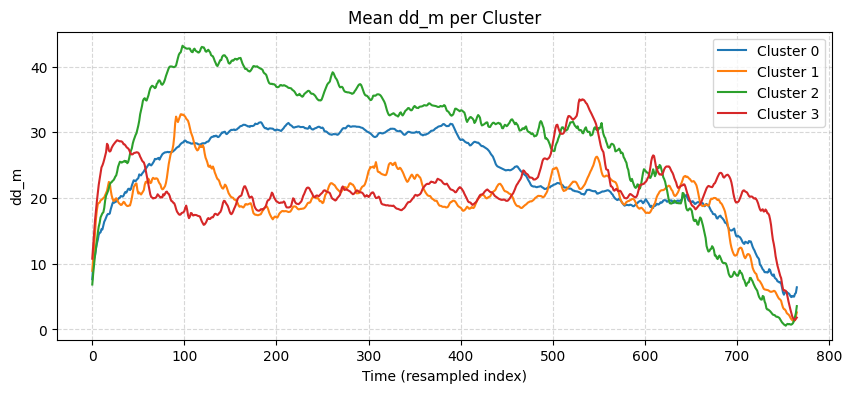

Mean value per cluster for constant features:


,RatioPayload
Cluster,
0,0.453
1,1.000
2,0.014
3,1.000


In [50]:
centroids = tskmeans.cluster_centers_

const_features = ['RatioPayload']
non_const_features = [f for f in ts_features if f not in const_features]

for f_idx, fname in enumerate(ts_features):
    if fname in non_const_features:
        plt.figure(figsize=(10,4))
        for cluster in range(k_opt):
            plt.plot(centroids[cluster, :, f_idx], label=f'Cluster {cluster}')
        plt.title(f'Mean {fname} per Cluster')
        plt.xlabel('Time (resampled index)')
        plt.ylabel(fname)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

if const_features:
    cluster_means = pd.DataFrame(columns=const_features)
    for cluster in range(k_opt):
        mean_vals = centroids[cluster].mean(axis=0)
        cluster_means.loc[cluster] = [mean_vals[ts_features.index(f)] for f in const_features]
    cluster_means.index.name = 'Cluster'
    cluster_means = cluster_means.astype(float)
    
    print("Mean value per cluster for constant features:")
    display(cluster_means.round(3))


Cluster 2 — Empty high-speed downhill return

Payload ratio: 0.00

Speed: Highest (peaks near 10 m/s)

Altitude: Strong continuous decrease

Distance: Longest

Vibrations (εZ): Increasing over time

Temperature: Increasing

This cluster corresponds to empty trucks driving downhill at high speed.
Because the vehicle is empty, it can travel faster.
Despite no payload, temperature still rises due to high speed, braking and vibration on downhill haul roads.

Physical meaning: Return trip from dump site back to shovel.

Cluster 1 — Fully loaded uphill transport

Payload ratio: 1.00

Speed: Moderate (~4–5 m/s)

Altitude: Strong continuous increase

Distance: Medium

Vibrations (εZ): High at the beginning, then decreasing

Temperature: Gradually increasing

This cluster represents loaded trucks climbing uphill.
The dumper carries a full load and moves steadily at moderate speed while gaining altitude.
The increase in temperature is caused by high engine torque and tire deformation under load.
The slight reduction in vibration over time suggests more stable motion as speed becomes steady.

Physical meaning: hauling from loading area to dumping area.



Cluster 0 — Medium-load flat transport

Payload ratio: ~0.48

Speed: Stable (~6 m/s)

Altitude: Nearly flat

Vibrations: Low and stable

Temperature: Slightly decreasing

Distance: Medium

This cluster represents horizontal or mildly sloped transport with partial load.
The stable speed and low vibration indicate smooth cruising conditions with limited mechanical stress.

Physical meaning: Internal transport or circulation inside the mine.

Cluster 3 — Light-load rough downhill driving

Payload ratio: 0.125

Speed: Very irregular, increases over time

Altitude: Large drop, especially in the second half

Vibrations: Strong increase

Temperature: Decreasing

This cluster corresponds to lightly loaded trucks descending steep or rough terrain.
The increase in speed and strong vibrations reflect aggressive downhill driving, braking, and uneven surfaces.
Temperature decreases because engine load is low and gravity assists motion.

Physical meaning: Light-load downhill transport (e.g., partially loaded or positioning runs).

## f) Visualize clusters spatially

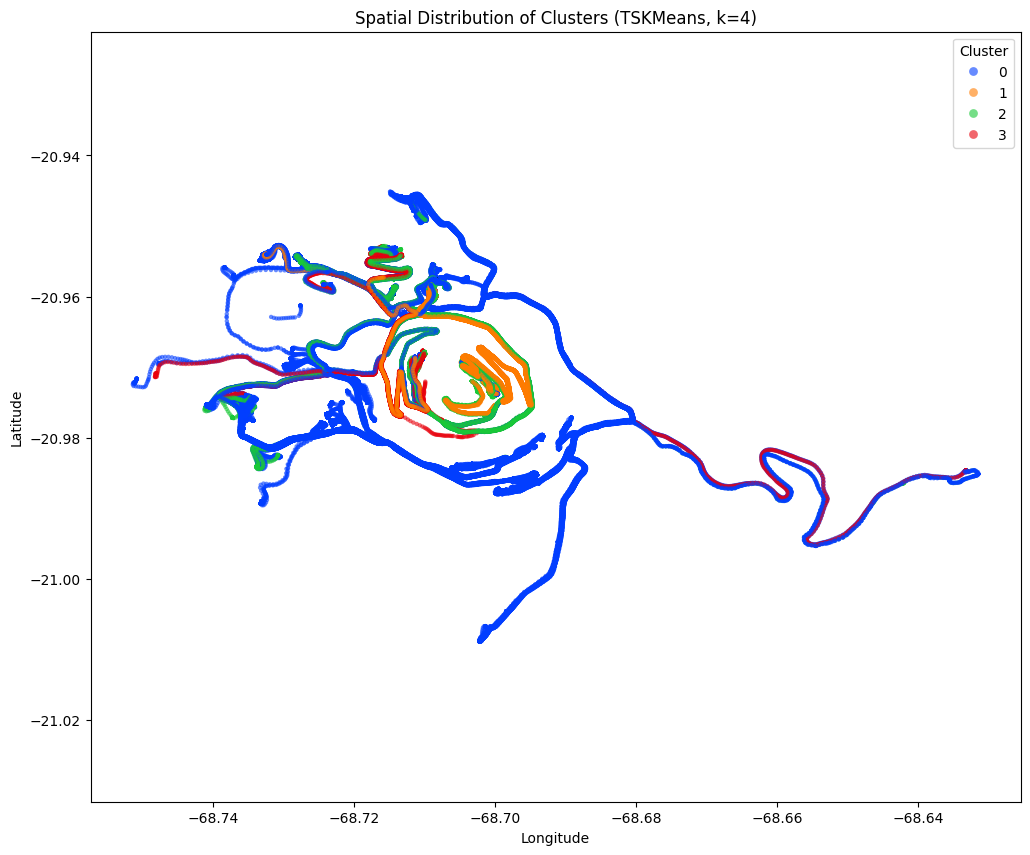

In [51]:
df_map = df_ts.dropna(subset=['Latitude_dd', 'Longitude_dd']).copy()
if 'cluster_ts' not in df_map.columns:
    raise ValueError("Column 'cluster_ts' not found in df_ts")

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_map,
    x='Longitude_dd',
    y='Latitude_dd',
    hue='cluster_ts',
    palette='bright',
    s=10,
    alpha=0.6,
    linewidth=0
)
plt.title(f"Spatial Distribution of Clusters (TSKMeans, k={k_opt})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal') 
plt.legend(title='Cluster', markerscale=2)
plt.show()



This map shows where the different TSKMeans clusters occur on the mine site.
Each color represents a different type of trajectory.

We can see that each cluster follows specific haul roads and areas of the mine.
Some clusters are mainly located on long transport routes, while others are concentrated around central operating zones.

This spatial consistency confirms that the time-series clustering is meaningful: trajectories grouped together also follow similar physical paths, which reflects real vehicle operations.

## 6) Geographical trajectory clustering (DTW)

In this section, we cluster trajectories based only on their geometrical paths (Latitude, Longitude).
Unlike the previous sections, which focus on vehicle dynamics, this approach groups trips according to the routes they follow in space.

We use Dynamic Time Warping (DTW) to compare GPS trajectories that may have different lengths or speeds.

## a) Build GPS trajectories

In [52]:
# Select GPS data
df_gps = df_ts.dropna(subset=['Latitude_dd', 'Longitude_dd']).copy()

gps_features = ['Latitude_dd', 'Longitude_dd']

# Build trajectories per phase
gps_trajectories = []
gps_phase_ids = []

for phase in df_gps['phaseNb'].unique():
    df_phase = df_gps[df_gps['phaseNb'] == phase].sort_values('Time_utc')
    X = df_phase[gps_features].values
    if X.shape[0] > 1:
        gps_trajectories.append(X)
        gps_phase_ids.append(phase)

print(f"Number of GPS trajectories: {len(gps_trajectories)}")


Number of GPS trajectories: 366


## b) Resample GPS trajectories

In [53]:
target_length = 40

resampler = TimeSeriesResampler(sz=target_length)
gps_resampled = resampler.fit_transform(gps_trajectories)

print("Resampled shape:", gps_resampled.shape)

Resampled shape: (366, 40, 2)


## c) Elbow Method for DTW K-Means

Fitting DTW-KMeans for k=6


c:\Users\natha\Documents\Programmation\Git\ProjetMichelin\env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Fitting DTW-KMeans for k=7


c:\Users\natha\Documents\Programmation\Git\ProjetMichelin\env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Fitting DTW-KMeans for k=8


...

c:\Users\natha\Documents\Programmation\Git\ProjetMichelin\env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Fitting DTW-KMeans for k=18


c:\Users\natha\Documents\Programmation\Git\ProjetMichelin\env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Fitting DTW-KMeans for k=19


c:\Users\natha\Documents\Programmation\Git\ProjetMichelin\env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


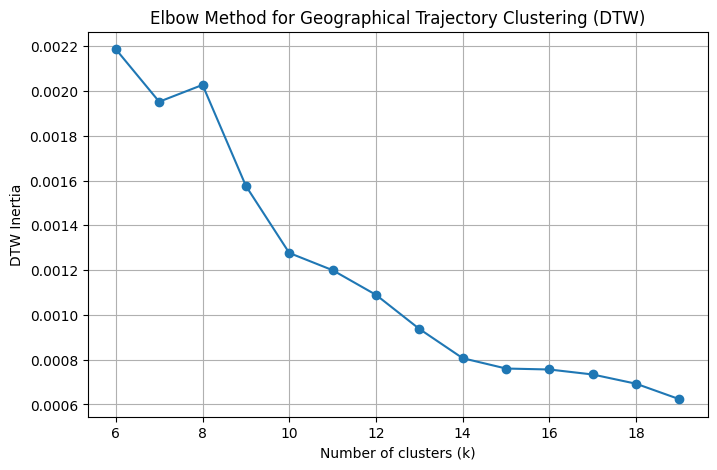

In [54]:
inertia_geo = []
K_range = range(6, 20)

for k in K_range:
    print(f"Fitting DTW-KMeans for k={k}")
    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        random_state=42,
        n_jobs=-1
    )
    km.fit(gps_resampled)
    inertia_geo.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_geo, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("DTW Inertia")
plt.title("Elbow Method for Geographical Trajectory Clustering (DTW)")
plt.grid(True)
plt.show()


## d) DTW K-Means clustering

In [55]:
k_geo = 12

dtw_km = TimeSeriesKMeans(
    n_clusters=k_geo,
    metric="dtw",
    random_state=42,
    n_jobs=-1
)

geo_labels = dtw_km.fit_predict(gps_resampled)

print("DTW clustering completed")

c:\Users\natha\Documents\Programmation\Git\ProjetMichelin\env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


DTW clustering completed


## e) Assign GPS clusters to the dataset

In [56]:
# Map phase -> geographical cluster
phase_to_geo_cluster = dict(zip(gps_phase_ids, geo_labels))

df_ts['geo_cluster'] = df_ts['phaseNb'].map(phase_to_geo_cluster)

## f) Visualize geographical clusters

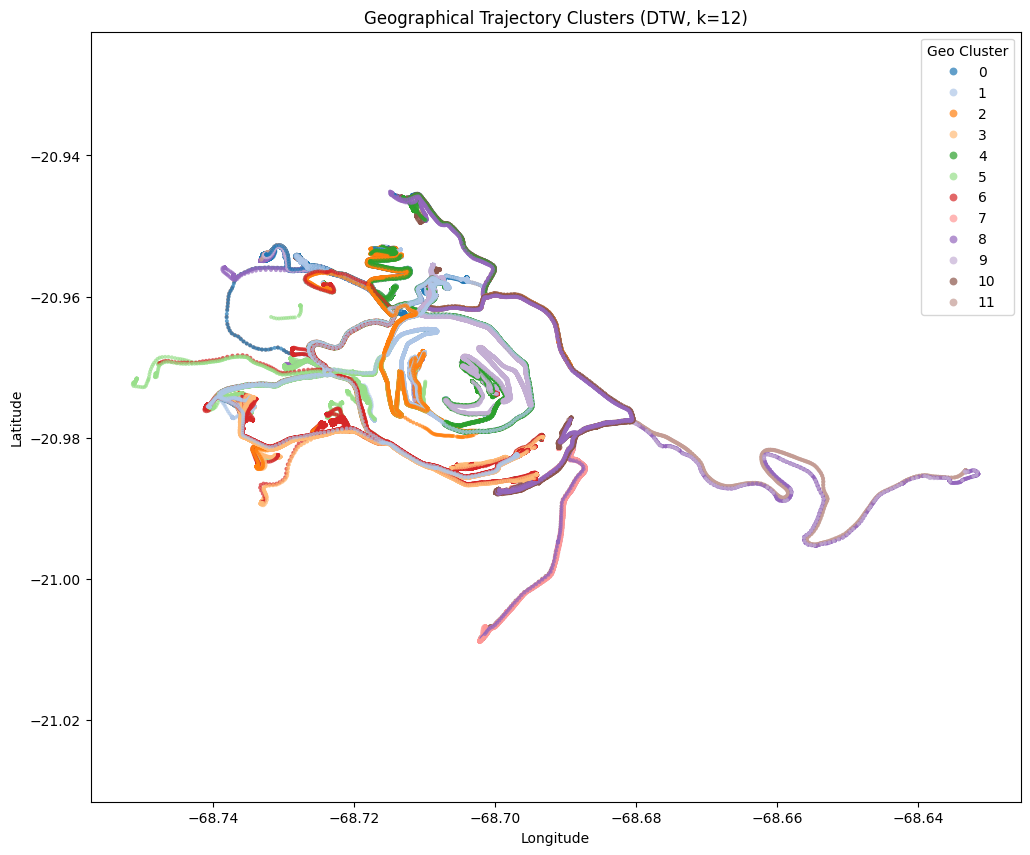

In [57]:
plt.figure(figsize=(12,10))
sns.scatterplot(
    data=df_ts.dropna(subset=['Latitude_dd','Longitude_dd']),
    x='Longitude_dd',
    y='Latitude_dd',
    hue='geo_cluster',
    palette='tab20',
    s=8,
    alpha=0.7,
    linewidth=0
)

plt.title(f"Geographical Trajectory Clusters (DTW, k={k_geo})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal')
plt.legend(title="Geo Cluster", markerscale=2)
plt.show()


In [58]:
geo_profiles = df_ts.groupby('geo_cluster').agg({
    'Speed_mps': 'mean',
    'RatioPayload': 'mean',
    'Temperature_K_3': 'mean',
    'epsilonZ': 'mean',
    'dd_m': 'sum'
}).round(3)

geo_profiles


,Speed_mps,RatioPayload,Temperature_K_3,epsilonZ,dd_m
geo_cluster,,,,,
0,1.938,0.254,327.435,24.449,113056.595
1,2.720,0.011,329.242,27.474,317576.706
2,2.127,0.447,322.723,26.126,253054.067
3,6.369,1.000,334.938,27.798,219513.106
4,4.621,0.000,332.745,34.546,363186.080
5,3.148,0.501,334.056,28.120,167679.729
6,3.164,0.000,336.265,25.794,268142.942
7,4.060,0.600,326.812,27.911,54218.121
8,5.556,0.573,333.290,26.369,256729.102


Several meaningful patterns appear across the geographical clusters.

First, the payload ratio varies strongly by area: clusters 1, 4 and 9 are almost always associated with loaded trucks (RatioPayload ≈ 1), while clusters 2, 5, 8 and 10 mainly correspond to empty vehicles, showing that routes are not used in the same way for freight transport. Second, temperature is clearly linked to geography, with some clusters operating in much colder conditions (e.g., cluster 6 at about 320.9 K) and others in much hotter environments (e.g., cluster 9 at about 337.6 K), which directly affects tire thermal behavior. Finally, mechanical stress and distance traveled also differ across routes: clusters 4 and 5 have very large dd_m values, corresponding to long or major routes, while clusters 7 and 9 represent more local trajectories; moreover, cluster 4 shows very high epsilonZ, indicating strong vertical stresses. 

Altogether, these results confirm that route geometry and location strongly influence vehicle operating conditions and tire loading.